In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(
    "/Users/kashakjoshi/stock_prediction_project/artifacts/raw/ITC_NS.csv",
    skiprows=3,
    names=["Date","Close","High","Low","Open","Volume"]
)

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,161.223816,161.992278,160.718825,161.421414,2636761
2015-01-02,161.728806,162.541179,161.267726,161.267726,6853849
2015-01-05,162.365540,163.265737,161.399469,161.904460,8556295
2015-01-06,158.193863,162.211831,157.644960,161.882487,13597291
2015-01-07,155.251755,159.840587,155.010235,156.766728,12421217


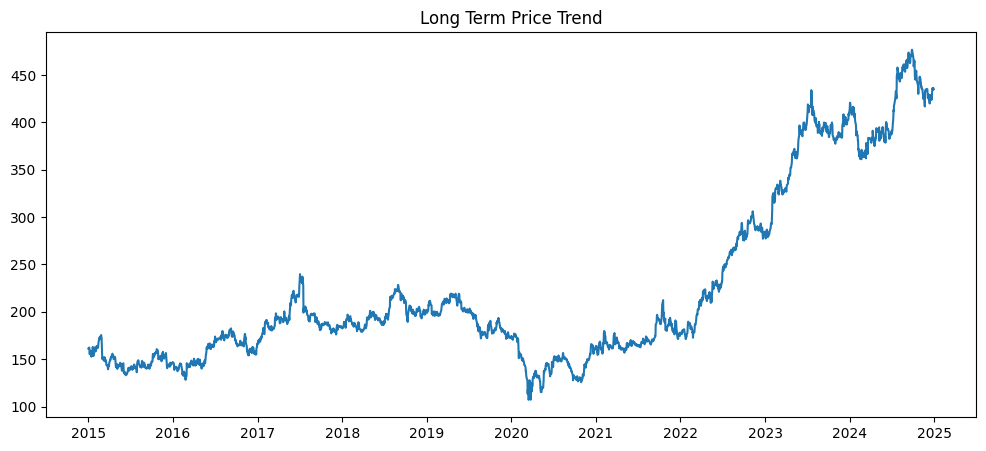

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Close"])
plt.title("Long Term Price Trend")
plt.show()

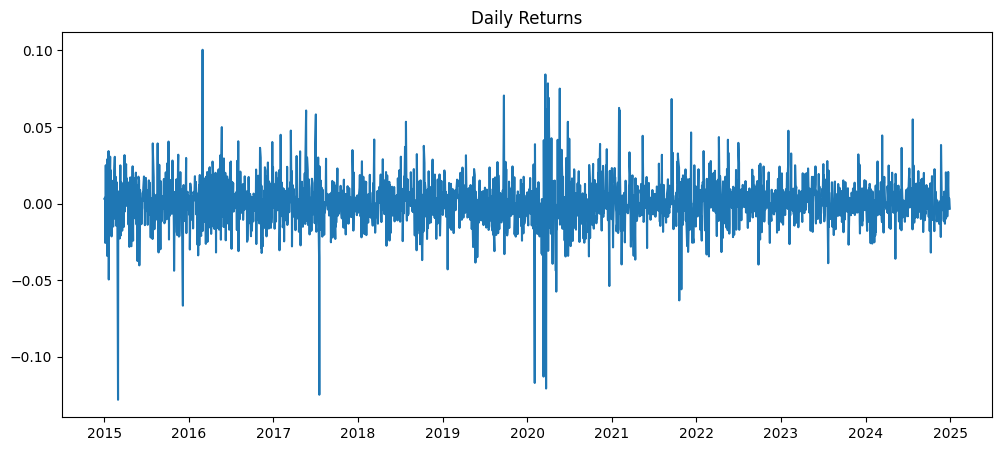

In [8]:
df["returns"] = df["Close"].pct_change()

plt.figure(figsize=(12,5))
plt.plot(df["returns"])
plt.title("Daily Returns")
plt.show()

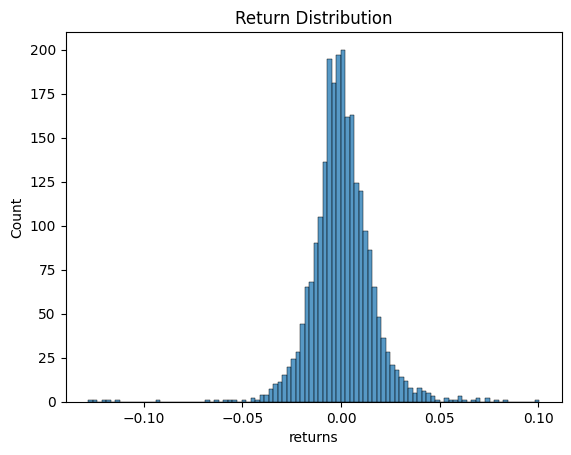

In [9]:
import seaborn as sns

sns.histplot(df["returns"].dropna(), bins=100)
plt.title("Return Distribution")
plt.show()

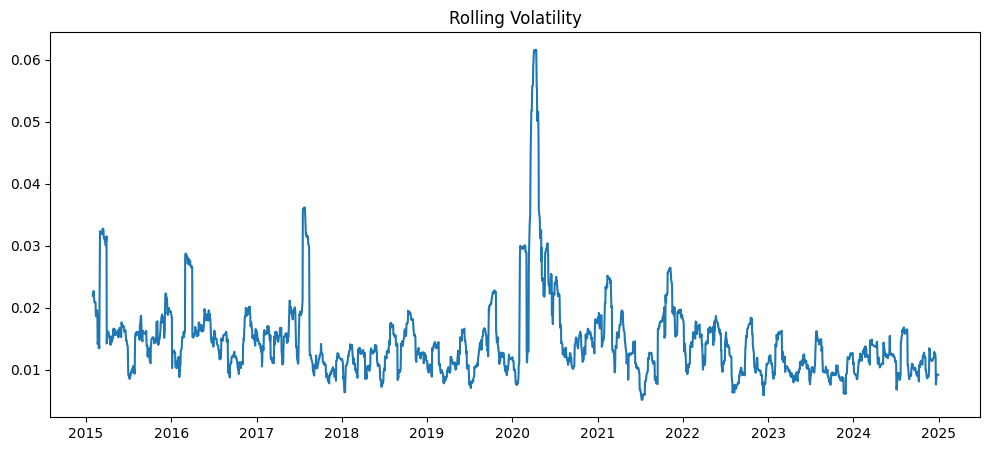

In [10]:
df["volatility"] = df["returns"].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(df["volatility"])
plt.title("Rolling Volatility")
plt.show()

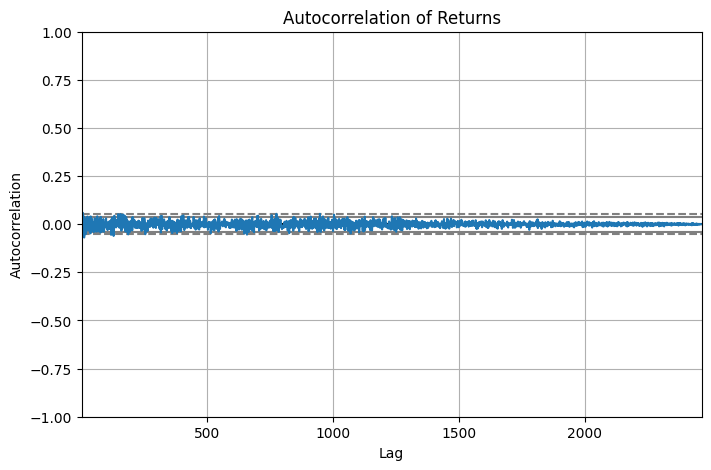

In [11]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(8,5))
autocorrelation_plot(df["returns"].dropna())
plt.title("Autocorrelation of Returns")
plt.show()

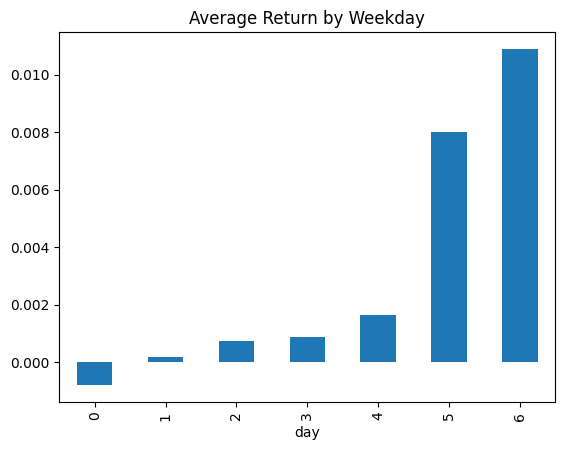

In [12]:
df["day"] = df.index.dayofweek

df.groupby("day")["returns"].mean().plot(kind="bar")

plt.title("Average Return by Weekday")
plt.show()

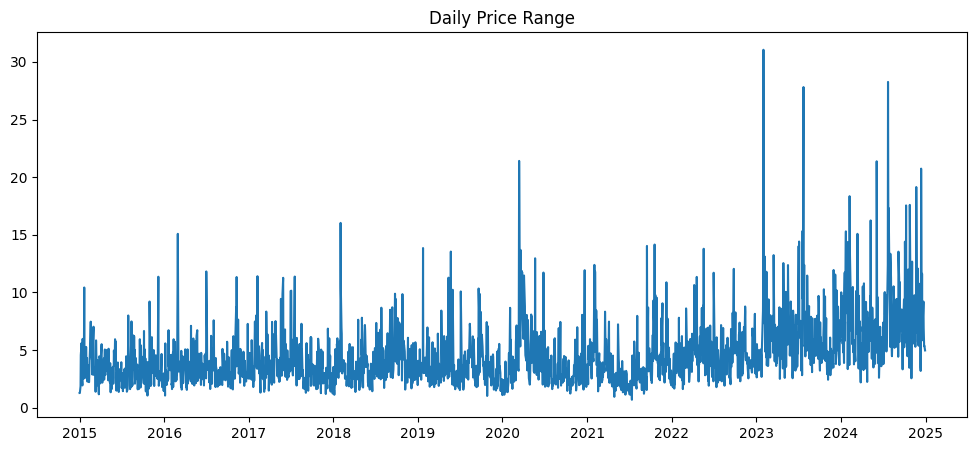

In [13]:
df["range"] = df["High"] - df["Low"]

plt.figure(figsize=(12,5))
plt.plot(df["range"])
plt.title("Daily Price Range")
plt.show()

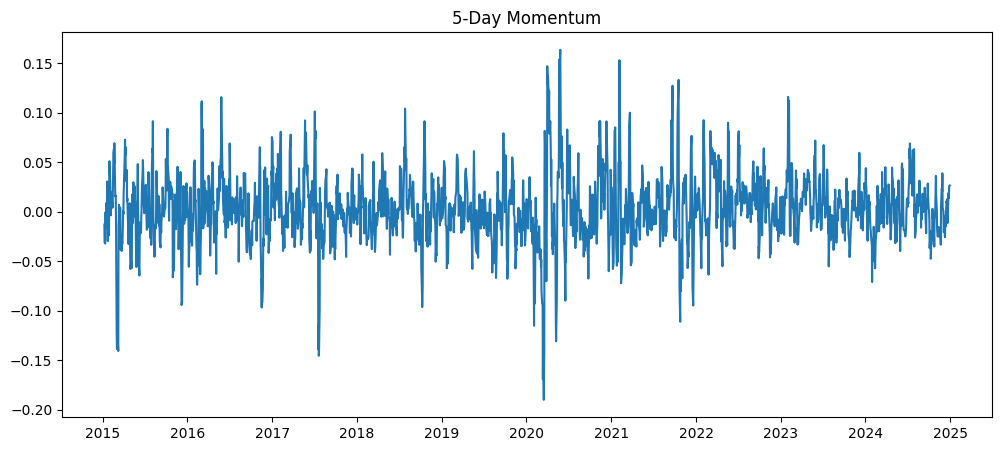

In [14]:
df["momentum_5"] = df["Close"].pct_change(5)

plt.figure(figsize=(12,5))
plt.plot(df["momentum_5"])
plt.title("5-Day Momentum")
plt.show()

In [15]:
df.isna().sum()

Close          0
High           0
Low            0
Open           0
Volume         0
returns        1
volatility    20
day            0
range          0
momentum_5     5
dtype: int64

In [16]:
df.index.duplicated().sum()

np.int64(0)

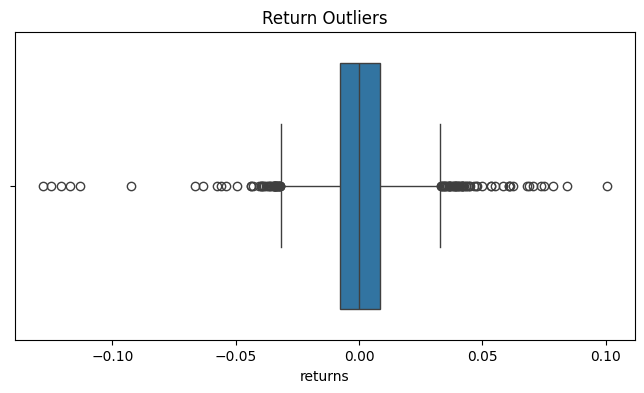

In [17]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["returns"].dropna())
plt.title("Return Outliers")
plt.show()

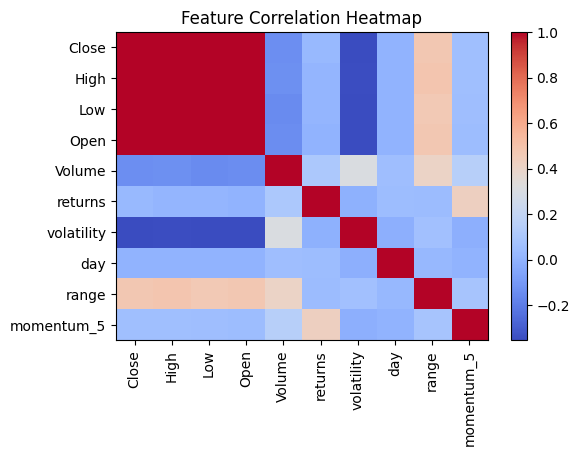

In [19]:
corr = df.corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
df["target"] = df["returns"].shift(-1)

df[["returns", "target"]].head(10)

,returns,target
Date,,
2015-01-01,NaN,0.003132
2015-01-02,0.003132,0.003937
2015-01-05,0.003937,-0.025693
2015-01-06,-0.025693,-0.018598
2015-01-07,-0.018598,0.025032
2015-01-08,0.025032,-0.015177
2015-01-09,-0.015177,0.002662
2015-01-12,0.002662,0.006288
2015-01-13,0.006288,-0.034157


In [21]:
split_ratio = 0.8

split_index = int(len(df) * split_ratio)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1972, 11)
Test Shape: (494, 11)


In [22]:
features = [
    "returns",
    "volatility",
    "day",
    "range",
    "momentum_5",
    "Volume"
]

target = "target"

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(X_train.shape, X_test.shape)

(1972, 6) (494, 6)
